# Практическая работа №3.6. Нейронные сети

**Тема:** построение модели нейронной сети прямого распространения для прогнозирования стоимости недвижимости по данным `kc_house_data.csv`.

**Задача:** выполнить вычисления по модели нейронной сети прямого распространения и провести анализ полученной модели по СКО. Для сравнения также строится модель линейной регрессии.

В работе используются метрики:

- **СКО / MSE** – средняя квадратическая ошибка;
- **RMSE** – корень из средней квадратической ошибки;
- **MAE** – средняя абсолютная ошибка;
- **MAPE** – средняя абсолютная процентная ошибка;
- **R²** – коэффициент детерминации.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:

DATA_PATH = Path("kc_house_data.csv")
df = pd.read_csv(DATA_PATH)
print("Размер набора данных:", df.shape)
display(df.head())

Размер набора данных: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0000,3,1.0000,1180,5650,1.0000,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.2570,1340,5650
1,6414100192,20141209T000000,538000.0000,3,2.2500,2570,7242,2.0000,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.3190,1690,7639
2,5631500400,20150225T000000,180000.0000,2,1.0000,770,10000,1.0000,0,0,3,6,770,0,1933,0,98028,47.7379,-122.2330,2720,8062
3,2487200875,20141209T000000,604000.0000,4,3.0000,1960,5000,1.0000,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.3930,1360,5000
4,1954400510,20150218T000000,510000.0000,3,2.0000,1680,8080,1.0000,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.0450,1800,7503


In [3]:
# Общая информация о данных
print("Информация о типах данных:")
display(df.dtypes.to_frame("Тип данных"))

print("Количество пропусков по столбцам:")
display(df.isna().sum().to_frame("Пропуски").T)

print("Описательная статистика числовых признаков:")
display(df.describe().T)

Информация о типах данных:


,Тип данных
id,int64
date,object
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64


Количество пропусков по столбцам:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
Пропуски,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
id,21613.0000,4580301520.8650,2876565571.3120,1000102.0000,2123049194.0000,3904930410.0000,7308900445.0000,9900000190.0000
price,21613.0000,540088.1418,367127.1965,75000.0000,321950.0000,450000.0000,645000.0000,7700000.0000
bedrooms,21613.0000,3.3708,0.9301,0.0000,3.0000,3.0000,4.0000,33.0000
bathrooms,21613.0000,2.1148,0.7702,0.0000,1.7500,2.2500,2.5000,8.0000
sqft_living,21613.0000,2079.8997,918.4409,290.0000,1427.0000,1910.0000,2550.0000,13540.0000
sqft_lot,21613.0000,15106.9676,41420.5115,520.0000,5040.0000,7618.0000,10688.0000,1651359.0000
floors,21613.0000,1.4943,0.5400,1.0000,1.0000,1.5000,2.0000,3.5000
waterfront,21613.0000,0.0075,0.0865,0.0000,0.0000,0.0000,0.0000,1.0000
view,21613.0000,0.2343,0.7663,0.0000,0.0000,0.0000,0.0000,4.0000
condition,21613.0000,3.4094,0.6507,1.0000,3.0000,3.0000,4.0000,5.0000


## Подготовка данных

Для модели прогнозируется показатель `price`. Из даты продажи выделяются год и месяц. Также добавляются признаки возраста дома и факта ремонта.

Идентификатор `id` и исходный текстовый столбец `date` в модель не включаются, так как сами по себе не являются содержательными количественными признаками для прогнозирования цены.

In [4]:
# Копия данных, чтобы не изменять исходный датафрейм
work_df = df.copy()

# Преобразование даты продажи
work_df["date"] = pd.to_datetime(work_df["date"], errors="coerce")
work_df["sale_year"] = work_df["date"].dt.year
work_df["sale_month"] = work_df["date"].dt.month

# Дополнительные признаки
work_df["house_age"] = work_df["sale_year"] - work_df["yr_built"]
work_df["is_renovated"] = (work_df["yr_renovated"] > 0).astype(int)
work_df["years_since_renovation"] = np.where(
    work_df["yr_renovated"] > 0,
    work_df["sale_year"] - work_df["yr_renovated"],
    0
)

# Удаление строк с пропусками, если они появились после преобразований
work_df = work_df.dropna().reset_index(drop=True)

# Целевая переменная
TARGET = "price"

X = work_df.drop(columns=["id", "date", TARGET])
y = work_df[TARGET]

print("Размер матрицы признаков X:", X.shape)
print("Размер целевой переменной y:", y.shape)
display(X.head())

Размер матрицы признаков X: (21613, 23)
Размер целевой переменной y: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,is_renovated,years_since_renovation
0,3,1.0000,1180,5650,1.0000,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.2570,1340,5650,2014,10,59,0,0
1,3,2.2500,2570,7242,2.0000,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.3190,1690,7639,2014,12,63,1,23
2,2,1.0000,770,10000,1.0000,0,0,3,6,770,0,1933,0,98028,47.7379,-122.2330,2720,8062,2015,2,82,0,0
3,4,3.0000,1960,5000,1.0000,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.3930,1360,5000,2014,12,49,0,0
4,3,2.0000,1680,8080,1.0000,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.0450,1800,7503,2015,2,28,0,0


In [5]:
# Деление на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (17290, 23)
Тестовая выборка: (4323, 23)


## Нормирование и кодирование признаков

Для нейронной сети важно привести числовые признаки к сопоставимому масштабу, поэтому используется стандартизация. Категориальные признаки кодируются методом one-hot encoding.

В качестве категориальных признаков рассматриваются признаки с ограниченным количеством значений: `zipcode`, `floors`, `waterfront`, `view`, `condition`, `grade`.

In [6]:
categorical_features = [
    "zipcode",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade"
]

numeric_features = [col for col in X.columns if col not in categorical_features]

print("Числовые признаки:")
print(numeric_features)
print("\nКатегориальные признаки:")
print(categorical_features)

# Совместимость с разными версиями scikit-learn
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

Числовые признаки:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age', 'is_renovated', 'years_since_renovation']

Категориальные признаки:
['zipcode', 'floors', 'waterfront', 'view', 'condition', 'grade']


## Функции для расчета качества моделей

СКО в задании соответствует метрике MSE: среднему значению квадратов ошибок прогноза.

In [7]:
def regression_metrics(y_true, y_pred):
    """Расчет метрик качества регрессионной модели."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {
        "СКО_MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "R2": r2
    }


def fit_and_evaluate(model_name, regressor, X_train, X_test, y_train, y_test):
    """Обучение модели и расчет качества на тестовой выборке."""
    start = time.time()

    model = TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", regressor)
        ]),
        transformer=StandardScaler()
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    metrics = regression_metrics(y_test, y_pred)
    metrics["Модель"] = model_name
    metrics["Время_обучения_сек"] = elapsed

    return model, y_pred, metrics

## Линейная регрессия

Линейная регрессия используется как базовая модель для сравнения с нейронной сетью.

In [8]:
results = []
fitted_models = {}
predictions = {}

linear_model, linear_pred, linear_metrics = fit_and_evaluate(
    model_name="Линейная регрессия",
    regressor=LinearRegression(),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

fitted_models["Линейная регрессия"] = linear_model
predictions["Линейная регрессия"] = linear_pred
results.append(linear_metrics)

pd.DataFrame([linear_metrics])

,СКО_MSE,RMSE,MAE,MAPE_%,R2,Модель,Время_обучения_сек
0,24345301004.5223,156029.8081,90303.9599,17.0224,0.8390,Линейная регрессия,0.1395


## Нейронная сеть прямого распространения

Используется `MLPRegressor` – многослойный персептрон, то есть нейронная сеть прямого распространения. Ниже проверяются несколько конфигураций с разным количеством скрытых слоев и нейронов.

In [9]:
# Конфигурации нейронной сети
nn_configs = [
    {
        "name": "Нейронная сеть 1: 1 скрытый слой, 16 нейронов",
        "hidden_layer_sizes": (16,),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 500
    },
    {
        "name": "Нейронная сеть 2: 1 скрытый слой, 32 нейрона",
        "hidden_layer_sizes": (32,),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 500
    },
    {
        "name": "Нейронная сеть 3: 2 скрытых слоя, 64 и 32 нейрона",
        "hidden_layer_sizes": (64, 32),
        "activation": "relu",
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 700
    },
    {
        "name": "Нейронная сеть 4: 2 скрытых слоя, 100 и 50 нейронов",
        "hidden_layer_sizes": (100, 50),
        "activation": "relu",
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "max_iter": 700
    }
]

for cfg in nn_configs:
    print("Обучается модель:", cfg["name"])

    nn_regressor = MLPRegressor(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation=cfg["activation"],
        solver="adam",
        alpha=cfg["alpha"],
        learning_rate_init=cfg["learning_rate_init"],
        max_iter=cfg["max_iter"],
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    )

    model, y_pred, metrics = fit_and_evaluate(
        model_name=cfg["name"],
        regressor=nn_regressor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    fitted_models[cfg["name"]] = model
    predictions[cfg["name"]] = y_pred
    results.append(metrics)

print("Обучение завершено.")

Обучается модель: Нейронная сеть 1: 1 скрытый слой, 16 нейронов
Обучается модель: Нейронная сеть 2: 1 скрытый слой, 32 нейрона
Обучается модель: Нейронная сеть 3: 2 скрытых слоя, 64 и 32 нейрона
Обучается модель: Нейронная сеть 4: 2 скрытых слоя, 100 и 50 нейронов
Обучение завершено.


## Сравнение качества моделей

Главная метрика для выполнения задания – СКО, то есть MSE. Чем меньше значение СКО, тем лучше модель.

In [10]:
results_df = pd.DataFrame(results)
results_df = results_df[[
    "Модель", "СКО_MSE", "RMSE", "MAE", "MAPE_%", "R2", "Время_обучения_сек"
]].sort_values("СКО_MSE").reset_index(drop=True)

# Более удобный вывод чисел
display(results_df.style.format({
    "СКО_MSE": "{:.2f}",
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}",
    "MAPE_%": "{:.2f}",
    "R2": "{:.4f}",
    "Время_обучения_сек": "{:.2f}"
}))

,Модель,СКО_MSE,RMSE,MAE,MAPE_%,R2,Время_обучения_сек
0,"Нейронная сеть 3: 2 скрытых слоя, 64 и 32 нейрона",17488081752.64,132242.51,72943.67,13.82,0.8843,5.49
1,"Нейронная сеть 1: 1 скрытый слой, 16 нейронов",17714155363.21,133094.54,74401.28,13.99,0.8828,5.23
2,"Нейронная сеть 2: 1 скрытый слой, 32 нейрона",18606844239.74,136406.91,74445.89,13.88,0.8769,3.89
3,"Нейронная сеть 4: 2 скрытых слоя, 100 и 50 нейронов",19072000513.38,138101.41,73787.56,13.84,0.8738,8.76
4,Линейная регрессия,24345301004.52,156029.81,90303.96,17.02,0.8390,0.14


In [11]:
# Таблица только с СКО
quality_table = results_df[["Модель", "СКО_MSE"]].copy()
quality_table.columns = ["Качество оценки", "СКО"]

display(quality_table.style.format({"СКО": "{:.2f}"}))

,Качество оценки,СКО
0,"Нейронная сеть 3: 2 скрытых слоя, 64 и 32 нейрона",17488081752.64
1,"Нейронная сеть 1: 1 скрытый слой, 16 нейронов",17714155363.21
2,"Нейронная сеть 2: 1 скрытый слой, 32 нейрона",18606844239.74
3,"Нейронная сеть 4: 2 скрытых слоя, 100 и 50 нейронов",19072000513.38
4,Линейная регрессия,24345301004.52


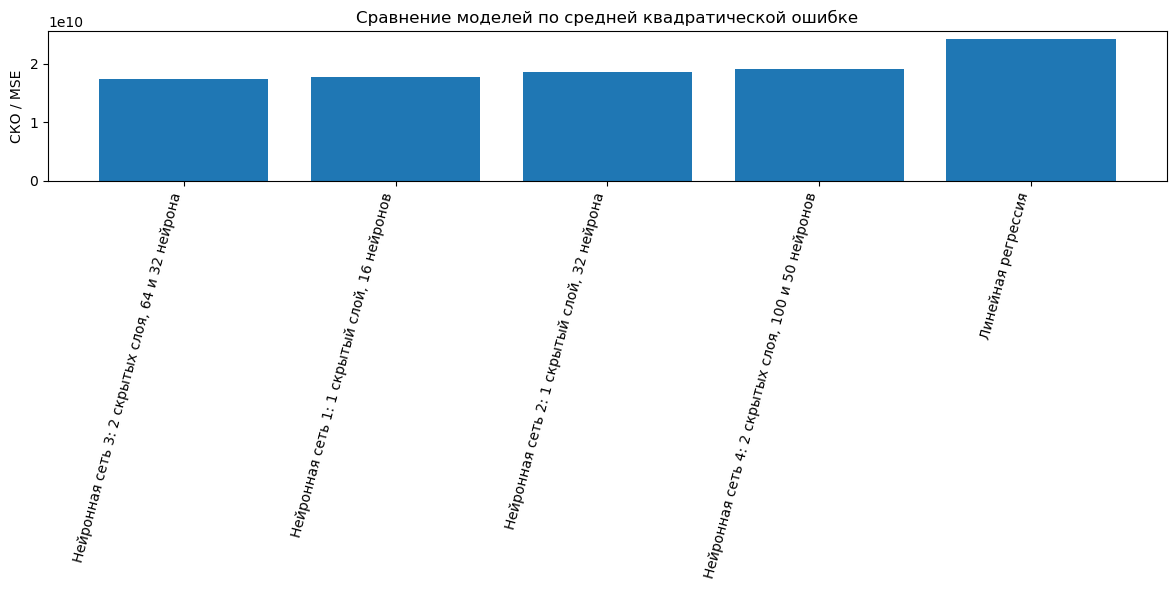

In [12]:
# Графическое сравнение моделей по СКО
plt.figure(figsize=(12, 6))
plt.bar(results_df["Модель"], results_df["СКО_MSE"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("СКО / MSE")
plt.title("Сравнение моделей по средней квадратической ошибке")
plt.tight_layout()
plt.show()

##  Анализ лучшей модели

В следующей ячейке автоматически выбирается модель с минимальной СКО и формируется краткий вывод.

In [13]:
best_row = results_df.iloc[0]
best_model_name = best_row["Модель"]
best_pred = predictions[best_model_name]

linear_row = results_df[results_df["Модель"] == "Линейная регрессия"].iloc[0]

mse_diff = linear_row["СКО_MSE"] - best_row["СКО_MSE"]
relative_improvement = mse_diff / linear_row["СКО_MSE"] * 100

conclusion = f"""
### Вывод по результатам моделирования

По результатам сравнения моделей наименьшее значение СКО показала модель **{best_model_name}**.

- СКО лучшей модели: **{best_row['СКО_MSE']:.2f}**;
- RMSE лучшей модели: **{best_row['RMSE']:.2f}**;
- MAE лучшей модели: **{best_row['MAE']:.2f}**;
- MAPE лучшей модели: **{best_row['MAPE_%']:.2f}%**;
- R² лучшей модели: **{best_row['R2']:.4f}**.

Для линейной регрессии СКО составила **{linear_row['СКО_MSE']:.2f}**. 
Разница между линейной регрессией и лучшей моделью по СКО равна **{mse_diff:.2f}**, 
что соответствует изменению качества примерно на **{relative_improvement:.2f}%** относительно линейной регрессии.

Следовательно, если значение СКО у нейронной сети ниже, чем у линейной регрессии, 
то нейронная сеть лучше аппроксимирует зависимость стоимости недвижимости от характеристик объекта. 
Это объясняется тем, что нейронная сеть способна учитывать нелинейные связи между признаками, 
тогда как линейная регрессия описывает зависимость только в линейной форме.
"""

display(Markdown(conclusion))


### Вывод по результатам моделирования

По результатам сравнения моделей наименьшее значение СКО показала модель **Нейронная сеть 3: 2 скрытых слоя, 64 и 32 нейрона**.

- СКО лучшей модели: **17488081752.64**;
- RMSE лучшей модели: **132242.51**;
- MAE лучшей модели: **72943.67**;
- MAPE лучшей модели: **13.82%**;
- R² лучшей модели: **0.8843**.

Для линейной регрессии СКО составила **24345301004.52**. 
Разница между линейной регрессией и лучшей моделью по СКО равна **6857219251.88**, 
что соответствует изменению качества примерно на **28.17%** относительно линейной регрессии.

Следовательно, если значение СКО у нейронной сети ниже, чем у линейной регрессии, 
то нейронная сеть лучше аппроксимирует зависимость стоимости недвижимости от характеристик объекта. 
Это объясняется тем, что нейронная сеть способна учитывать нелинейные связи между признаками, 
тогда как линейная регрессия описывает зависимость только в линейной форме.


In [14]:
# Анализ ошибок лучшей модели
errors = best_pred - y_test

error_df = pd.DataFrame({
    "Фактическая цена": y_test.values,
    "Прогноз": best_pred,
    "Ошибка": errors,
    "Абсолютная ошибка": np.abs(errors),
    "Ошибка, %": np.abs(errors) / y_test.values * 100
})

print("Первые строки таблицы ошибок лучшей модели:")
display(error_df.head(10))

Первые строки таблицы ошибок лучшей модели:


,Фактическая цена,Прогноз,Ошибка,Абсолютная ошибка,"Ошибка, %"
735,365000.0000,369084.0241,4084.0241,4084.0241,1.1189
2830,865000.0000,823252.3465,-41747.6535,41747.6535,4.8263
4106,1038000.0000,1133646.8978,95646.8978,95646.8978,9.2145
16218,1490000.0000,2059459.6043,569459.6043,569459.6043,38.2188
19964,711000.0000,697531.2322,-13468.7678,13468.7678,1.8943
1227,211000.0000,234101.6314,23101.6314,23101.6314,10.9486
18849,790000.0000,785004.5936,-4995.4064,4995.4064,0.6323
19369,680000.0000,661150.8558,-18849.1442,18849.1442,2.7719
20164,384500.0000,487656.2061,103156.2061,103156.2061,26.8287
7139,605000.0000,573757.1328,-31242.8672,31242.8672,5.1641


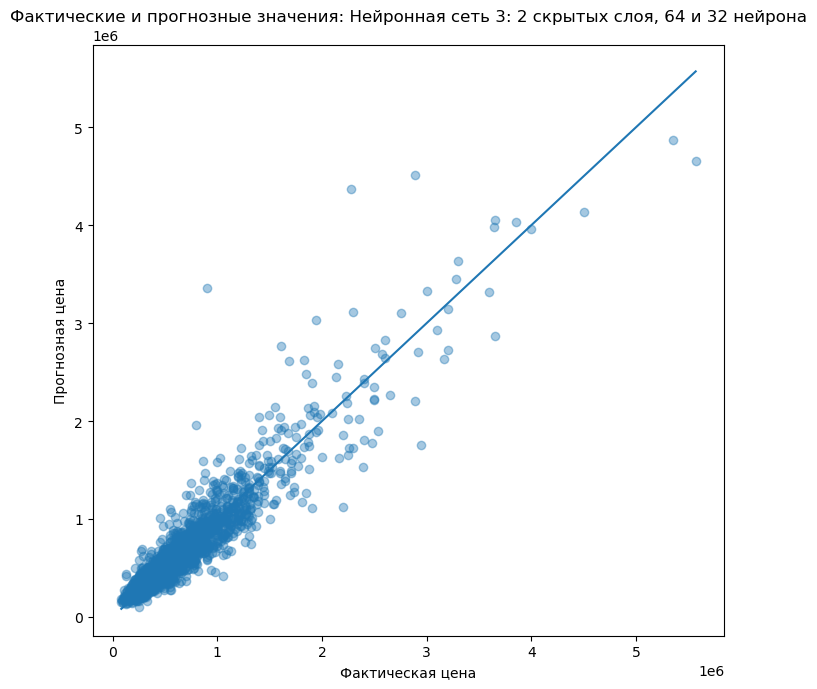

In [15]:
# График фактических и прогнозных значений для лучшей модели
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.4)
plt.xlabel("Фактическая цена")
plt.ylabel("Прогнозная цена")
plt.title(f"Фактические и прогнозные значения: {best_model_name}")

# Линия идеального прогноза
min_price = min(y_test.min(), best_pred.min())
max_price = max(y_test.max(), best_pred.max())
plt.plot([min_price, max_price], [min_price, max_price])

plt.tight_layout()
plt.show()

По результатам сравнения наилучшее качество показала нейронная сеть 3 с двумя скрытыми слоями по 64 и 32 нейрона. У нее минимальная среднеквадратическая ошибка: СКО = 17 488 081 752,64, минимальное значение RMSE = 132 242,51, а также наибольший коэффициент детерминации R² = 0,8843. Это означает, что модель объясняет около 88,43 % изменчивости цены домов.

Линейная регрессия показала худший результат: СКО = 24 345 301 004,52, RMSE = 156 029,81, MAE = 90 303,96, MAPE = 17,02 %, R² = 0,8390. Это говорит о том, что линейная модель хуже описывает зависимость цены от характеристик домов, так как связь между признаками и ценой имеет нелинейный характер.

Таким образом, применение нейронной сети позволило повысить точность прогнозирования по сравнению с линейной регрессией. Наиболее эффективной оказалась нейронная сеть с двумя скрытыми слоями 64 и 32 нейрона, так как она обеспечивает минимальную ошибку и лучшее значение R² при сравнительно небольшом времени обучения.